# Import

In [4]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# qt.metrics.average_gate_fidelity??


In [ ]:
9774-316-9458=0
11780-58-316=11406

11406

In [ ]:
def average_gate_fidelity_trace_decreasing(oper, target=None):
    """
    Average gate fidelity for a possibly trace-decreasing quantum map.

    The quantum map is

        E(rho) = sum_k K_k rho K_k.dag()

    and the average fidelity relative to target unitary U is

        F_avg =
            [sum_k Tr(K_k.dag() K_k)
             + sum_k |Tr(U.dag() K_k)|^2]
            / [d(d + 1)].

    For a trace-preserving map,

        sum_k K_k.dag() K_k = I,

    and the first term reduces to d, recovering the standard
    average-gate-fidelity formula.

    Parameters
    ----------
    oper : qutip.Qobj or list[qutip.Qobj]
        A square operator, superoperator, or list of Kraus operators.

        A square non-unitary operator V is interpreted as the
        one-Kraus map

            rho -> V rho V.dag().

    target : qutip.Qobj or None
        Target unitary. If None, the identity is used.

    Returns
    -------
    fidelity : float
        Leakage-inclusive average gate fidelity.
    """

    # Convert input to Kraus representation.
    if isinstance(oper, (list, tuple)):
        kraus_form = list(oper)

    elif isinstance(oper, qt.Qobj):
        if oper.issuper:
            kraus_form = qt.to_kraus(oper)
        elif oper.isoper:
            kraus_form = [oper]
        else:
            raise TypeError(
                "oper must be an operator, superoperator, "
                "or a list of Kraus operators."
            )

    else:
        raise TypeError(
            "oper must be a qutip.Qobj or a list of qutip.Qobj."
        )

    if len(kraus_form) == 0:
        raise ValueError("The Kraus list is empty.")

    d_out, d_in = kraus_form[0].shape

    if d_out != d_in:
        raise ValueError(
            "Only square Kraus operators are supported."
        )

    d = d_in

    for i, K in enumerate(kraus_form):
        if not isinstance(K, qt.Qobj):
            raise TypeError(
                f"Kraus operator {i} is not a qutip.Qobj."
            )

        if K.shape != (d, d):
            raise ValueError(
                f"Kraus operator {i} has shape {K.shape}; "
                f"expected {(d, d)}."
            )

    if target is None:
        target = qt.qeye(d)

    if not isinstance(target, qt.Qobj):
        raise TypeError("target must be a qutip.Qobj.")

    if target.shape != (d, d):
        raise ValueError(
            f"target has shape {target.shape}; expected {(d, d)}."
        )

    # Average survival contribution.
    survival_term = sum(
        np.real((K.dag() * K).tr())
        for K in kraus_form
    )

    # Target-overlap contribution.
    overlap_term = sum(
        np.abs((target.dag() * K).tr()) ** 2
        for K in kraus_form
    )

    fidelity = (
        survival_term + overlap_term
    ) / (d * (d + 1))

    return float(np.real_if_close(fidelity))


In [ ]:


def project_operator(operator, selected_indices):
    """
    Extract a square sub-block of a Qobj operator.

    This is useful for QuTiP 4.7.5, where extract_states()
    may not be available for operators.

    Parameters
    ----------
    operator : qutip.Qobj
        Full-space operator.

    selected_indices : list[int]
        Basis-state indices retained in the projected space.

    Returns
    -------
    projected_operator : qutip.Qobj
        Operator restricted to the selected subspace.
    """

    selected_indices = list(selected_indices)

    matrix = operator.full()
    projected_matrix = matrix[
        np.ix_(selected_indices, selected_indices)
    ]

    d = len(selected_indices)

    return qt.Qobj(
        projected_matrix,
        dims=[[d], [d]],
    )



In [7]:

def main():
    # ============================================================
    # Key editable parameters
    # ============================================================

    # Coupling between computational state |1> and leakage state |2>.
    coupling = 1.0

    # Evolution time.
    #
    # coupling * gate_time determines the leakage amplitude.
    # Try:
    #   gate_time = 0.0       -> no leakage
    #   gate_time = 0.2       -> small leakage
    #   gate_time = np.pi/4   -> 50% leakage from |1>
    #   gate_time = np.pi/2   -> complete leakage from |1>
    gate_time = 0.4

    # Computational states in the full three-level Hilbert space.
    logical_indices = [0, 1]

    # ============================================================
    # Build a three-level system
    # ============================================================

    # Basis states |0>, |1>, and |2>.
    ket0 = qt.basis(3, 0)
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    # Hamiltonian:
    #
    # H = g (|1><2| + |2><1|)
    #
    # State |0> is unaffected, while |1> coherently exchanges
    # population with leakage state |2>.
    H_full = coupling * (
        ket1 * ket2.dag()
        + ket2 * ket1.dag()
    )

    # Full three-level propagator.
    #
    # U_full is unitary in the complete Hilbert space.
    U_full = (-1j * H_full * gate_time).expm()

    # ============================================================
    # Project onto the computational subspace {|0>, |1>}
    # ============================================================

    V = project_operator(
        U_full,
        logical_indices,
    )

    # Target operation: identity gate in the computational subspace.
    #
    # This example asks how closely the projected evolution acts as
    # the identity while accounting for population leaking to |2>.
    U_target = qt.qeye(2)

    # ============================================================
    # Calculate fidelity
    # ============================================================

    # New leakage-inclusive formula.
    F_leakage = average_gate_fidelity_trace_decreasing(
        V,
        target=U_target,
    )

    # QuTiP standard formula.
    #
    # qt.to_super(V) describes rho -> V rho V.dag(), but this map is
    # trace decreasing. QuTiP nevertheless replaces the first term
    # by d, which assumes trace preservation.
    V_super = qt.to_super(V)

    F_qutip = qt.metrics.average_gate_fidelity(
        V_super,
        target=U_target,
    )

    # Average survival probability over Haar-random input states.
    #
    # For a d-dimensional input space:
    #
    # p_survival_avg = Tr(V.dag() V) / d.
    d = V.shape[0]

    average_survival = np.real(
        (V.dag() * V).tr()
    ) / d

    # Check how far V is from being unitary.
    unitarity_defect = (
        V.dag() * V - qt.qeye(d)
    ).norm()

    # ============================================================
    # Analytical values for this example
    # ============================================================

    # The projected operator is analytically
    #
    # V = diag(1, cos(g t)).
    c = np.cos(coupling * gate_time)

    F_analytic = (
        1.0 + c**2 + np.abs(1.0 + c)**2
    ) / 6.0

    survival_analytic = (
        1.0 + c**2
    ) / 2.0

    # ============================================================
    # Print results
    # ============================================================

    np.set_printoptions(
        precision=6,
        suppress=True,
    )

    print("=" * 65)
    print("Full three-level Hamiltonian H_full")
    print("=" * 65)
    print(H_full.full())

    print("\n" + "=" * 65)
    print("Full propagator U_full")
    print("=" * 65)
    print(U_full.full())

    print("\n" + "=" * 65)
    print("Projected computational-space operator V")
    print("=" * 65)
    print(V.full())

    print("\nV.dag() * V =")
    print((V.dag() * V).full())

    print("\n" + "=" * 65)
    print("Fidelity results")
    print("=" * 65)

    print(
        f"coupling                         = {coupling:.6f}"
    )
    print(
        f"gate_time                       = {gate_time:.6f}"
    )
    print(
        f"cos(coupling * gate_time)       = {c:.10f}"
    )

    print()
    print(
        "QuTiP standard fidelity          = "
        f"{F_qutip:.10f}"
    )
    print(
        "Leakage-inclusive fidelity       = "
        f"{F_leakage:.10f}"
    )
    print(
        "Analytical leakage fidelity      = "
        f"{F_analytic:.10f}"
    )

    print()
    print(
        "Average computational survival   = "
        f"{average_survival:.10f}"
    )
    print(
        "Analytical average survival      = "
        f"{survival_analytic:.10f}"
    )
    print(
        "Unitarity defect ||V†V-I||       = "
        f"{unitarity_defect:.10e}"
    )

    print()
    print(
        "Difference: QuTiP - generalized  = "
        f"{F_qutip - F_leakage:.10e}"
    )


if __name__ == "__main__":
    main()

Full three-level Hamiltonian H_full
[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]]

Full propagator U_full
[[1.      +0.j       0.      +0.j       0.      +0.j      ]
 [0.      +0.j       0.921061+0.j       0.      -0.389418j]
 [0.      +0.j       0.      -0.389418j 0.921061+0.j      ]]

Projected computational-space operator V
[[1.      +0.j 0.      +0.j]
 [0.      +0.j 0.921061+0.j]]

V.dag() * V =
[[1.      +0.j 0.      +0.j]
 [0.      +0.j 0.848353+0.j]]

Fidelity results
coupling                         = 1.000000
gate_time                       = 0.400000
cos(coupling * gate_time)       = 0.9210609940

QuTiP standard fidelity          = 0.9484125571
Leakage-inclusive fidelity       = 0.9231381162
Analytical leakage fidelity      = 0.9231381162

Average computational survival   = 0.9241766773
Analytical average survival      = 0.9241766773
Unitarity defect ||V†V-I||       = 1.5164664533e-01

Difference: QuTiP - generalized  = 2.5274440888e-02


# Ideal fidelity

In [4]:
f_theta = pd.read_csv('figure/data/data_xgate_theta_mstep_3e4_npz.txt')
f_phi = pd.read_csv('figure/data/data_xgate_phi_mstep_1e3_npz.txt')
f_cz = pd.read_csv('figure/data/data_cz_fidelity_npz_select.txt')


In [ ]:
f_ideal_157_qt = np.array([
-0.47695268, -0.89061680, -1.93926583, -2.79094210 ,
-3.36333343, -3.77252960, -4.12038403, -4.47706848 ,
-4.73374511, -4.98881570, -5.17035187, -5.40682250 ,
-5.61859122, -5.94862329, -6.24194963, -6.53016446 ,
-6.62084628, -6.90134353 ,
])
f_ideal_157_trace = np.array([
-0.31929714, -0.72783439, -1.76516297, -2.61528131 ,
-3.18893146, -3.59911069, -3.94576335, -4.30228971 ,
-4.56064647, -4.81290623, -4.99644666, -5.23254507 ,
-5.44709937, -5.77782044, -6.07549701, -6.36236729 ,
-6.47793283, -6.76165496 ,
])


params2 = f_theta[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2'
                    ]].to_numpy()    

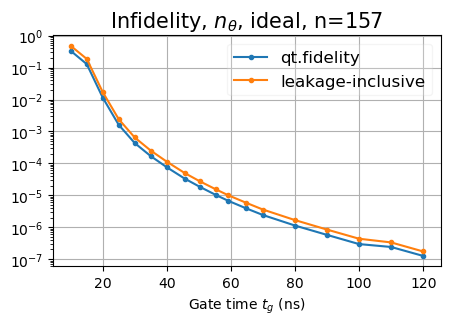

In [15]:
fig, ax = plt.subplots(figsize=(5,3))
# plt.plot(params2[:,0], 10**f_theta['f_78_charge']  , '.-', label=r'')
plt.plot(params2[:,0], 10**f_ideal_157_qt  , '.-', label=r'qt.fidelity')
plt.plot(params2[:,0], 10**f_ideal_157_trace  , '.-', label=r'leakage-inclusive')

# plt.plot(params2[:,0], np.abs(10**f_ideal_157_qt - 10**f_ideal_157_trace) , 'x--', label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'Infidelity, $n_\theta$, ideal, n=157 ', fontsize=15)
plt.grid()
legend = plt.legend( loc="best", fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [16]:
f_ideal_160_qt = np.array([
-0.60543886, -0.75216288, -0.88532710, -1.12281715 ,
-1.48689846, -1.63808567, -1.69961775, -1.74066149 ,
-1.84482049, -1.90450043, -2.07199956, -2.19215012 ,
-2.27969953, -2.45578378, -2.53352759, -2.45459650 ,
-2.63978566, -2.62000011, -2.67156173 ,
])
f_ideal_160_trace = np.array([
-0.45274732, -0.59018161, -0.73582954, -1.00300988 ,
-1.31452595, -1.47741648, -1.52588756, -1.56589755 ,
-1.68608855, -1.73372244, -1.89860451, -2.02206732 ,
-2.10386616, -2.28244838, -2.36253825, -2.28020037 ,
-2.46528653, -2.44602271, -2.49633782 ,
])

f_theta = pd.read_csv('figure/data/data_xgate_phi_mstep_1e3_npz.txt')

params2 = f_theta[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2'
                    ]].to_numpy()    

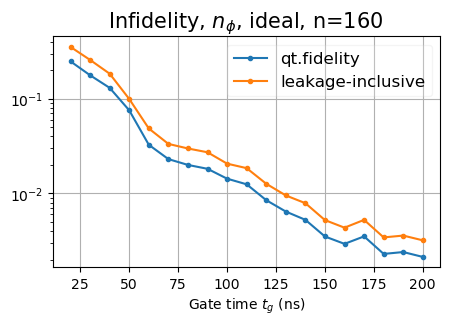

In [19]:
fig, ax = plt.subplots(figsize=(5,3))
plt.plot(params2[:,0], 10**f_ideal_160_qt  , '.-', label=r'qt.fidelity')
plt.plot(params2[:,0], 10**f_ideal_160_trace  , '.-', label=r'leakage-inclusive')

# plt.plot(params2[:,0], np.abs(10**f_ideal_157_qt - 10**f_ideal_157_trace) , 'x--', label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'Infidelity, $n_\phi$, ideal, n=160 ', fontsize=15)
plt.grid()
legend = plt.legend( loc="best", fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [7]:


fidelity_ideal_list = np.array([
[-0.5014073889205216] ,
[-0.22356995427313642] ,
[-0.2898333905675301] ,
[-0.4765225503270354] ,
[-0.9953324865779963] ,
[-1.0937007821823284] ,
[-0.9647691314506014] ,
[-0.956306280320073] ,
[-1.128424470801423] ,
[-1.2678143357978173] ,
[-1.5608314314032934] ,
[-2.0553195969018567] ,
[-2.472414471885312] ,
[-2.235310716273299] ,
[-2.0114375656899064] ,
[-2.2336286300247177] ,
[-2.7335708224504547] ,
[-3.0597272127918567] ,
[-2.9018328559863087] ,
[-2.956390972292078] ,
[-3.1829097210614234] ,
[-3.24667154875247] ,
[-3.232444892492138] ,
[-3.3947770094777683] ,
[-3.6281873012785266] ,
[-3.736418416838863] ,
[-3.879744039590469] ,
[-4.175170034783538] ,
[-4.314018666957953] ,
[-4.250246533659474] ,
])


fidelity_ideal_list.flatten()


array([-0.50140739, -0.22356995, -0.28983339, -0.47652255, -0.99533249,
       -1.09370078, -0.96476913, -0.95630628, -1.12842447, -1.26781434,
       -1.56083143, -2.0553196 , -2.47241447, -2.23531072, -2.01143757,
       -2.23362863, -2.73357082, -3.05972721, -2.90183286, -2.95639097,
       -3.18290972, -3.24667155, -3.23244489, -3.39477701, -3.6281873 ,
       -3.73641842, -3.87974404, -4.17517003, -4.31401867, -4.25024653])

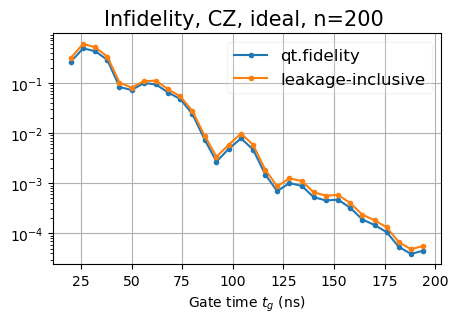

In [10]:
fig, ax = plt.subplots(figsize=(5,3))
plt.plot(f_cz['tg'], 10**f_cz['f_200']  , '.-', label=r'qt.fidelity')
plt.plot(f_cz['tg'], 10**fidelity_ideal_list.flatten()  , '.-', label=r'leakage-inclusive')

# plt.plot(params2[:,0], np.abs(10**f_ideal_157_qt - 10**f_ideal_157_trace) , 'x--', label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'Infidelity, CZ, ideal, n=200 ', fontsize=15)
plt.grid()
legend = plt.legend( loc="best", fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

# Fidelity after re-optimize

In [11]:
f_60 = np.array([
-0.54365858, -0.28017197, -0.44107243, -0.90923460 ,
-1.19925911, -1.17585189, -1.05601843, -0.97188930 ,
-1.13464832, -1.27320826, -1.62397994, -2.23522414 ,
-2.97267254, -2.37475419, -2.05000572, -2.26195855 ,
-2.76500812, -3.07475984, -2.90448424, -2.95808909 ,
-3.18591485, -3.24807240, -3.23610900, -3.39726775 ,
-3.62828630 ,
])

f_1000 = np.array([
-0.49269787, -0.28445641, -0.09398666, -0.36819753 ,
-0.77510595, -0.48674690, -0.73008487, -0.96815111 ,
-1.12839933, -1.26895197, -1.57569819, -2.16948837 ,
-2.79427023, -2.30141952, -2.00387113, -2.22442840 ,
-2.72350874, -3.05098060, -2.90016169, -2.95314112 ,
-3.17697366, -3.23918175, -3.22963949, -3.39014632 ,
-3.62252321 ,
])

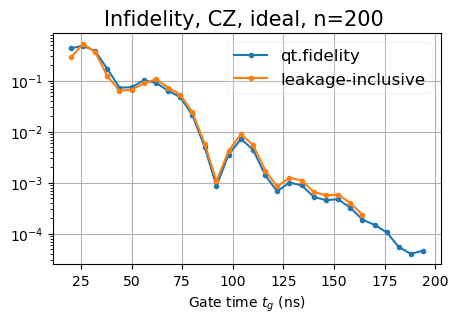

In [13]:
fig, ax = plt.subplots(figsize=(5,3))
plt.plot(f_cz['tg'], 10**f_cz['f_60']  , '.-', label=r'qt.fidelity')
plt.plot(f_cz['tg'][:25], 10**f_60  , '.-', label=r'leakage-inclusive')

# plt.plot(params2[:,0], np.abs(10**f_ideal_157_qt - 10**f_ideal_157_trace) , 'x--', label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'Infidelity, CZ, ideal, n=200 ', fontsize=15)
plt.grid()
legend = plt.legend( loc="best", fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
## Noise CZ

params = np.array([
[91.948301, 0.017913, 0.02519] ,
[182.010007, 0.00788, 0.013127] ,
])

# -3.06910213
f_170us_60_tg12 = np.array([
-2.91495486 ,
])

# -4.26339398
f_170us_60_tg27 = np.array([
-3.58789360 ,
])

# Leakage-inclusive fidelity: unoptimized vs optimized pulses

All leakage-inclusive curves below use `average_gate_fidelity_trace_decreasing`.
The Theta optimized curve uses the latest corrected optimization with
`max_step_ideal=3e-4 ns`, matching the Theta fidelity runner. The corresponding
truncations are Phi `n_truc=160`, Theta `n_truc=157`, and CZ `n_truc=60`.

In [15]:
from pathlib import Path
import ast
import re

# Work whether the notebook kernel starts in the repository root or cz/.
repo = Path.cwd()
if not (repo / "xgate").exists():
    repo = repo.parent


def all_named_arrays(path, name):
    """Return every printed `name = np.array([...])` block, concatenated."""
    text = Path(path).read_text(encoding="utf-8", errors="replace")
    pattern = rf"{re.escape(name)}\s*=\s*np\.array\(\[(.*?)\]\)"
    blocks = re.findall(pattern, text, flags=re.S)
    values = []
    for block in blocks:
        values.extend(float(x) for x in re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?", block))
    return np.asarray(values)


def last_named_array(path, name):
    """Return the final cumulative printed array from an optimizer log."""
    text = Path(path).read_text(encoding="utf-8", errors="replace")
    pattern = rf"{re.escape(name)}\s*=\s*np\.array\(\[(.*?)\]\)"
    blocks = re.findall(pattern, text, flags=re.S)
    if not blocks:
        raise ValueError(f"No {name!r} array in {path}")
    return np.asarray([
        float(x) for x in re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?", blocks[-1])
    ])


def optimized_xgate_params(*paths):
    rows = []
    for path in paths:
        lines = Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
        for i, line in enumerate(lines[:-1]):
            if line.strip() == "Drive parameters:":
                rows.append(ast.literal_eval(lines[i + 1].strip()))
    return pd.DataFrame(rows, columns=["tg", "drive_amp_1", "drive_amp_2", "detune_1", "detune_2"])


def optimized_cz_params(path):
    rows = []
    lines = Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
    for line in lines:
        if line.strip().startswith("Optimized parameters:"):
            raw = line.split(":", 1)[1].strip().strip("[]")
            rows.append([float(x) for x in raw.split()])
    return pd.DataFrame(rows, columns=["tg", "drive_amp", "detune"])


def printed_triplets(path):
    rows = []
    for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        m = re.match(r"\s*\[\s*([-+0-9.eE]+)\s*,\s*([-+0-9.eE]+)\s*,\s*([-+0-9.eE]+)\s*\]", line)
        if m:
            rows.append([float(x) for x in m.groups()])
        elif rows:
            break
    return pd.DataFrame(rows, columns=["tg", "drive_amp", "detune"])

phi_old = repo / "xgate/data/fidelity_optimize/phi_trace_decreasing_n300_20260731_051907.log"
phi_resume = repo / "xgate/data/fidelity_optimize/phi_trace_decreasing_n300_resume10_20260801_093208.log"
# Corrected Theta optimization: max_step_ideal=3e-4, matching the fidelity runner.
theta_corrected = repo / "xgate/data/fidelity_optimize/theta_trace_decreasing_n300_mstep3e4_reopt_20260802_004241.log"
cz_old = repo / "cz/data/fidelity_optimize/cz_trace_decreasing_n60_20260731_051843.log"
cz_resume = repo / "cz/data/fidelity_optimize/cz_trace_decreasing_n60_resume25_20260801_093208.log"

phi_params_optimized = optimized_xgate_params(phi_old, phi_resume)
theta_params_optimized = optimized_xgate_params(theta_corrected)
cz_params_optimized = pd.concat([
    printed_triplets(repo / "cz/data/fidelity_optimize/cz_reopt.txt"),
    optimized_cz_params(cz_resume),
], ignore_index=True)

print("optimized pulse counts:", {
    "phi": len(phi_params_optimized),
    "theta": len(theta_params_optimized),
    "CZ": len(cz_params_optimized),
})
display(phi_params_optimized)
display(theta_params_optimized)
display(cz_params_optimized)

optimized pulse counts: {'phi': 19, 'theta': 18, 'CZ': 30}


,tg,drive_amp_1,drive_amp_2,detune_1,detune_2
0,19.991738,0.265505,0.173725,0.409908,0.460940
1,29.992774,0.216746,0.203921,0.390108,0.424457
2,40.014972,0.221317,0.156830,0.356421,0.385437
3,49.990204,0.216249,0.146398,0.354636,0.376272
4,59.994352,0.213420,0.142938,0.359182,0.378016
5,69.991101,0.209222,0.132819,0.353474,0.369706
6,80.007155,0.210573,0.122946,0.355789,0.371130
7,90.016240,0.220055,0.114891,0.351442,0.376879
8,99.992682,0.211710,0.114339,0.340293,0.362583
9,110.011473,0.211458,0.107187,0.341800,0.362944


,tg,drive_amp_1,drive_amp_2,detune_1,detune_2
0,10.112276,0.417301,0.074364,-0.088062,-0.047291
1,15.072566,0.305038,0.065019,-0.032653,-0.013751
2,20.042302,0.240822,0.059239,-0.019354,-0.009576
3,25.020839,0.180407,0.046271,-0.003880,0.001457
4,30.008808,0.145280,0.038018,0.000574,0.004073
5,34.999115,0.121822,0.032289,0.001887,0.004315
6,39.991616,0.105045,0.028058,0.002171,0.003988
7,45.572956,0.091008,0.024458,0.002102,0.003482
8,50.273280,0.081876,0.022072,0.001951,0.003063
9,55.267933,0.073988,0.020007,0.001756,0.002668


,tg,drive_amp,detune
0,20.042209,0.049978,0.039991
1,26.099981,0.026182,0.019529
2,32.057496,0.047462,0.021916
3,38.059233,0.041072,0.025351
4,44.046786,0.033734,0.028972
5,50.067794,0.036383,0.039999
6,56.065043,0.028997,0.039984
7,62.061713,0.020960,0.017575
8,68.034924,0.018637,0.016083
9,74.044345,0.016515,0.015571


In [16]:
# log10(infidelity), all evaluated with leakage-inclusive fidelity.
phi_unoptimized = all_named_arrays(
    repo / "xgate/data/fidelity_qutip/phi_trace_decreasing.log", "f_ideal_160"
)
phi_optimized = np.r_[
    last_named_array(phi_old, "f_optimize"),
    last_named_array(phi_resume, "f_optimize"),
]

theta_unoptimized = all_named_arrays(
    repo / "xgate/data/fidelity_qutip/trace_decreasing.log", "f_ideal_157"
)
theta_optimized = last_named_array(theta_corrected, "f_optimize")

cz_unoptimized = all_named_arrays(
    repo / "cz/data/fidelity_qutip/cz_ideal_trace_decreasing_n60_20260801_091651.log",
    "f_ideal_60",
)
cz_optimized = np.r_[
    last_named_array(cz_old, "f_60"),
    last_named_array(cz_resume, "f_60"),
]

for gate, unopt, opt in [
    ("phi", phi_unoptimized, phi_optimized),
    ("theta", theta_unoptimized, theta_optimized),
    ("CZ", cz_unoptimized, cz_optimized),
]:
    print(gate, "unoptimized/optimized points:", len(unopt), len(opt))

# QuTiP average-gate-fidelity baselines for the original pulse tables.
phi_qutip = pd.read_csv(repo / "figure/data/data_xgate_phi_mstep_1e3_npz.txt")["f_charge_160_npz"].to_numpy()
theta_qutip = pd.read_csv(repo / "figure/data/data_xgate_theta_mstep_3e4_npz.txt")["f_157_charge"].to_numpy()
cz_qutip = pd.read_csv(repo / "figure/data/data_cz_fidelity_npz_select.txt")["f_charge_60"].to_numpy()


phi unoptimized/optimized points: 19 19
theta unoptimized/optimized points: 18 18
CZ unoptimized/optimized points: 30 30


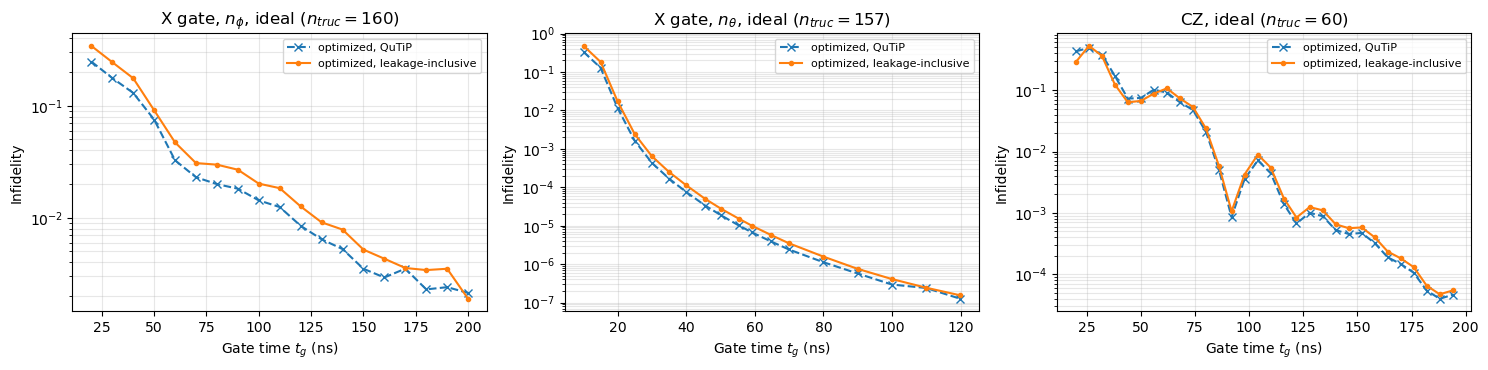

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
series = [
    (axes[0], r"X gate, $n_\phi$, ideal ($n_{truc}=160$)", phi_params_optimized["tg"], phi_unoptimized, phi_optimized, phi_qutip),
    (axes[1], r"X gate, $n_\theta$, ideal ($n_{truc}=157$)", theta_params_optimized["tg"], theta_unoptimized, theta_optimized, theta_qutip),
    (axes[2], r"CZ, ideal ($n_{truc}=60$)", cz_params_optimized["tg"], cz_unoptimized, cz_optimized, cz_qutip),
]
for ax, title, tg, unoptimized, optimized, qutip_fidelity in series:
    n = min(len(tg), len(unoptimized), len(optimized), len(qutip_fidelity))
    tg = np.asarray(tg)[:n]
    ax.plot(tg, 10**qutip_fidelity[:n], "x--", label="optimized, QuTiP")
    # ax.plot(tg, 10**unoptimized[:n], ".-", label="unoptimized, leakage-inclusive")
    ax.plot(tg, 10**optimized[:n], ".-", label="optimized, leakage-inclusive")
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Infidelity")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()

In [19]:
qutip_fidelity

array([-0.36874608, -0.31298903, -0.42261634, -0.76845001, -1.13856539,
       -1.12772268, -0.99288233, -1.04163815, -1.19719575, -1.32228755,
       -1.677043  , -2.29915223, -3.06910213, -2.44864877, -2.1442522 ,
       -2.35454828, -2.85784036, -3.17110381, -2.997641  , -3.05399916,
       -3.27984115, -3.34268562, -3.32580014, -3.49197201, -3.72260977,
       -3.83007849, -3.9735069 , -4.26339398, -4.39744373, -4.33251505])

## CZ noisy fidelity: old vs leakage-inclusive re-optimized pulses

The comparison uses the same two gate-time indices (`12` and `27`), `n_truc=60`, `T1=Tphi=170 us`, and the leakage-inclusive fidelity formula for both curves.

,source_index,old_tg,old_log10_infidelity,optimized_tg,optimized_log10_infidelity
0,12,91.948301,-2.914955,91.947295,-2.915227
1,27,182.010007,-3.587894,182.014628,-3.591410


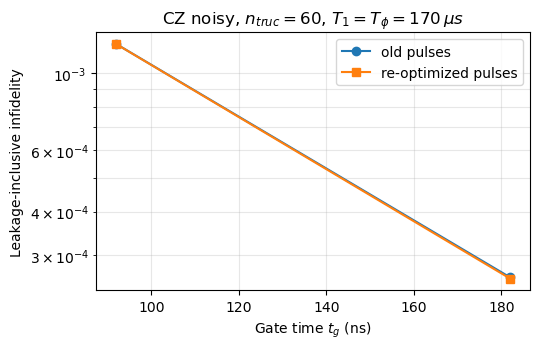

In [8]:
def fidelity_results_from_log(path):
    """Extract one-element noisy fidelity arrays in their printed order."""
    text = Path(path).read_text(encoding="utf-8", errors="replace")
    blocks = re.findall(
        r"^f_[^\n=]+\s*=\s*np\.array\(\[(.*?)\]\)",
        text,
        flags=re.S | re.M,
    )
    return np.asarray([
        float(re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?", block)[0])
        for block in blocks
    ])

old_cz_noisy_log = repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_tg12_27_20260731_034623.log"
optimized_cz_noisy_log = repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=170us_optimized_compare_tg12_27_20260802_005118.log"

old_cz_noisy = fidelity_results_from_log(old_cz_noisy_log)
optimized_cz_noisy = fidelity_results_from_log(optimized_cz_noisy_log)
old_cz_params = pd.read_csv(repo / "figure/data/data_cz_fidelity_npz_select.txt").iloc[[12, 27]]
optimized_cz_params_compare = pd.read_csv(
    repo / "cz/data/fidelity_optimize/cz_optimized_all30.csv"
).iloc[[12, 27]]

if len(optimized_cz_noisy) < 2:
    print("The optimized two-point noisy calculation is still running; rerun this cell when complete.")
else:
    fig, ax = plt.subplots(figsize=(5.5, 3.6))
    ax.plot(old_cz_params["tg"], 10**old_cz_noisy, "o-", label="old pulses")
    ax.plot(
        optimized_cz_params_compare["tg"],
        10**optimized_cz_noisy,
        "s-",
        label="re-optimized pulses",
    )
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Leakage-inclusive infidelity")
    ax.set_title(r"CZ noisy, $n_{truc}=60$, $T_1=T_\phi=170\,\mu s$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    display(pd.DataFrame({
        "source_index": [12, 27],
        "old_tg": old_cz_params["tg"].to_numpy(),
        "old_log10_infidelity": old_cz_noisy,
        "optimized_tg": optimized_cz_params_compare["tg"].to_numpy(),
        "optimized_log10_infidelity": optimized_cz_noisy,
    }))

## CZ noisy: currently completed re-optimized points

This cell does not wait for the continuation jobs. It extracts and plots every result already written to the three original noisy logs. Dashed curves are the old noisy reference columns stored in `data_cz_fidelity_npz_select.txt`; solid curves are leakage-inclusive results for the re-optimized pulses. The old stored columns were originally generated with the QuTiP fidelity convention, so the legend states this explicitly.

finished optimized noisy points: {170: 25, 30: 25, 3: 25}


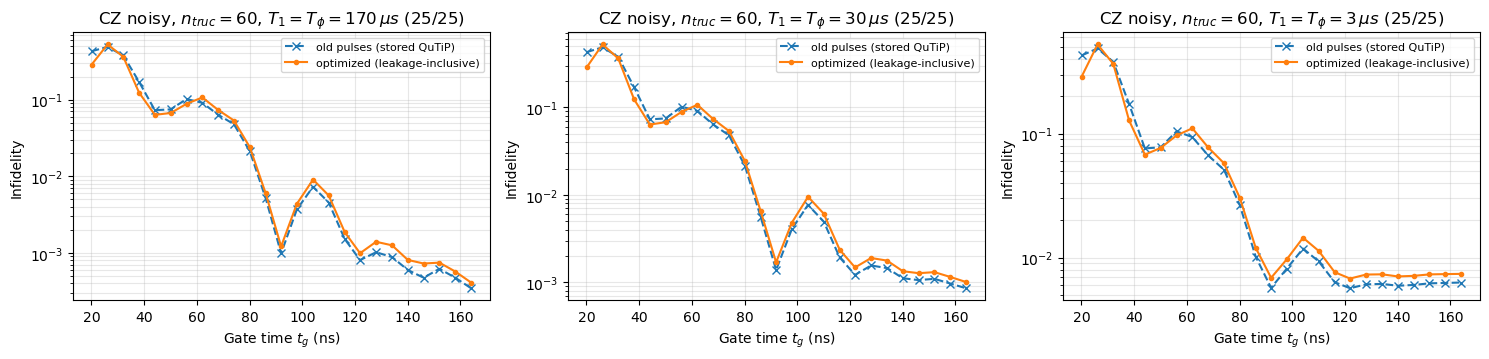

In [9]:
cz_reference = pd.read_csv(repo / "figure/data/data_cz_fidelity_npz_select.txt")
cz_reoptimized_25 = pd.read_csv(repo / "cz/data/fidelity_optimize/cz_optimized_all30.csv").iloc[:25]

partial_logs = {
    170: repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=170us_reopt_20260801_092525.log",
    30: repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=30us_reopt_20260801_092525.log",
    3: repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=3us_reopt_20260801_092525.log",
}
old_columns = {170: "f_60_170us", 30: "f_60_30us", 3: "f_60_3us"}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.7))
partial_cz_noisy = {}
for ax, t1 in zip(axes, [170, 30, 3]):
    optimized_values = fidelity_results_from_log(partial_logs[t1])
    count = len(optimized_values)
    partial_cz_noisy[t1] = optimized_values

    # Compare only indices for which the optimized noisy calculation finished.
    ax.plot(
        cz_reference["tg"].to_numpy()[:count],
        10**cz_reference[old_columns[t1]].to_numpy()[:count],
        "x--",
        label="old pulses (stored QuTiP)",
    )
    ax.plot(
        cz_reoptimized_25["tg"].to_numpy()[:count],
        10**optimized_values,
        ".-",
        label="optimized (leakage-inclusive)",
    )
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Infidelity")
    ax.set_title(rf"CZ noisy, $n_{{truc}}=60$, $T_1=T_\phi={t1}\,\mu s$ ({count}/25)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
print("finished optimized noisy points:", {t1: len(v) for t1, v in partial_cz_noisy.items()})

### CZ noisy: all six curves in one figure

One axis containing old and re-optimized curves for T1 = 170, 30, and 3 μs. Only currently completed optimized points are included.

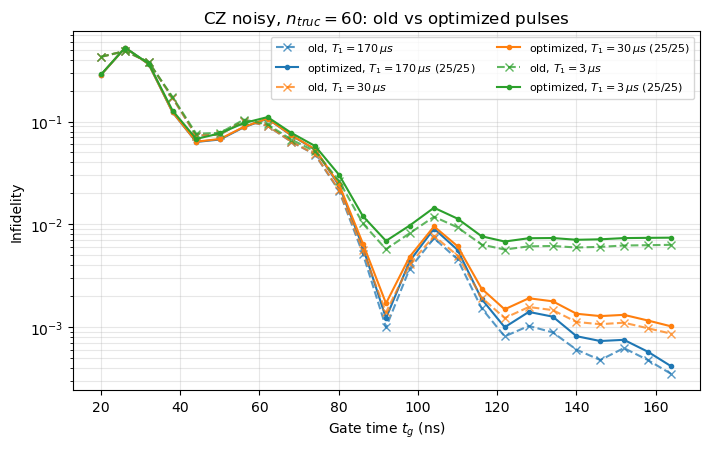

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
colors = {170: "C0", 30: "C1", 3: "C2"}

for t1 in [170, 30, 3]:
    optimized_values = fidelity_results_from_log(partial_logs[t1])
    count = len(optimized_values)
    color = colors[t1]

    ax.plot(
        cz_reference["tg"].to_numpy()[:count],
        10**cz_reference[old_columns[t1]].to_numpy()[:count],
        "x--",
        color=color,
        alpha=0.75,
        label=rf"old, $T_1={t1}\,\mu s$",
    )
    ax.plot(
        cz_reoptimized_25["tg"].to_numpy()[:count],
        10**optimized_values,
        ".-",
        color=color,
        label=rf"optimized, $T_1={t1}\,\mu s$ ({count}/25)",
    )

ax.set_yscale("log")
ax.set_xlabel(r"Gate time $t_g$ (ns)")
ax.set_ylabel("Infidelity")
ax.set_title(r"CZ noisy, $n_{truc}=60$: old vs optimized pulses")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()

# Complete noisy results: old versus optimized pulses

These cells load every completed noisy result. Optimized curves use the leakage-inclusive fidelity. The old reference columns in the original pulse tables use the stored QuTiP convention and are labelled accordingly. The current Theta noisy results use the five-point pulse file generated before the corrected `max_step=3e-4` re-optimization; rerun Theta noisy with the corrected pulses for the final comparison.

In [11]:
# ---------- X-gate: five equally spaced points ----------
phi_five = pd.read_csv(repo / "xgate/data/fidelity_optimize/phi_optimized_five_points_20260801_093726.csv")
theta_five = pd.read_csv(repo / "xgate/data/fidelity_optimize/theta_optimized_five_points_20260801_093726.csv")
phi_old_table = pd.read_csv(repo / "figure/data/data_xgate_phi_mstep_1e3_npz.txt")
theta_old_table = pd.read_csv(repo / "figure/data/data_xgate_theta_mstep_3e4_npz.txt")

xgate_new_logs = {
    ("phi", 170): repo / "xgate/data/fidelity_qutip/phi_noise_trace_decreasing_n300_T1=170us_five_points_restart_20260802_003545.log",
    ("phi", 30): repo / "xgate/data/fidelity_qutip/phi_noise_trace_decreasing_n300_T1=30us_five_points_restart_20260802_003545.log",
    ("theta", 170): repo / "xgate/data/fidelity_qutip/theta_noise_trace_decreasing_n300_T1=170us_five_points_restart_20260802_003545.log",
    ("theta", 30): repo / "xgate/data/fidelity_qutip/theta_noise_trace_decreasing_n300_T1=30us_five_points_restart_20260802_003545.log",
}

xgate_new = {
    ("phi", 170): all_named_arrays(xgate_new_logs[("phi", 170)], "f_170us_160"),
    ("phi", 30): all_named_arrays(xgate_new_logs[("phi", 30)], "f_30us_160"),
    ("theta", 170): all_named_arrays(xgate_new_logs[("theta", 170)], "f_170us_157"),
    ("theta", 30): all_named_arrays(xgate_new_logs[("theta", 30)], "f_30us_157"),
}

phi_idx = phi_five["source_index"].astype(int).to_numpy()
theta_idx = theta_five["source_index"].astype(int).to_numpy()
xgate_old = {
    ("phi", 170): phi_old_table["f_160_170us_npz"].to_numpy()[phi_idx],
    ("phi", 30): phi_old_table["f_160_30us_npz"].to_numpy()[phi_idx],
    ("theta", 170): theta_old_table["f_157_170us"].to_numpy()[theta_idx],
    ("theta", 30): theta_old_table["f_157_30us"].to_numpy()[theta_idx],
}

print("X-gate noisy point counts:", {key: len(value) for key, value in xgate_new.items()})

X-gate noisy point counts: {('phi', 170): 5, ('phi', 30): 5, ('theta', 170): 5, ('theta', 30): 5}


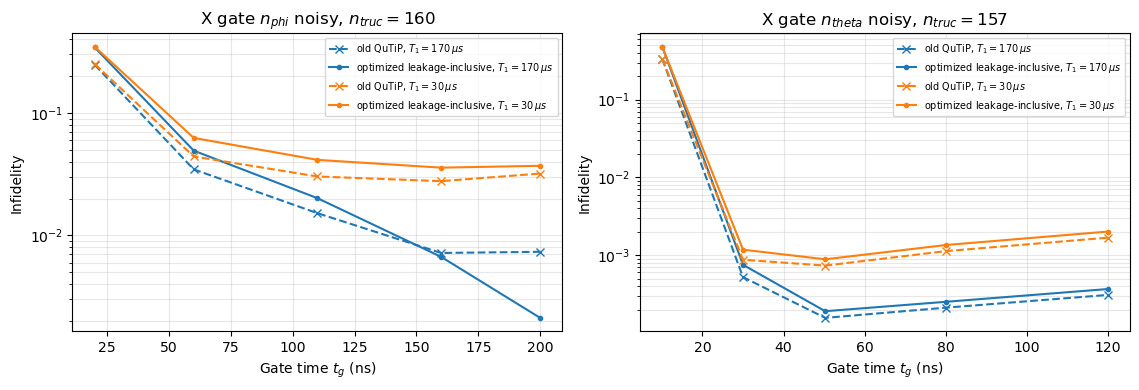

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for ax, mode, pulse, ntruc in [
    (axes[0], "phi", phi_five, 160),
    (axes[1], "theta", theta_five, 157),
]:
    for color, t1 in zip(["C0", "C1"], [170, 30]):
        tg = pulse["tg"].to_numpy()
        ax.plot(tg, 10**xgate_old[(mode, t1)], "x--", color=color,
                label=rf"old QuTiP, $T_1={t1}\,\mu s$")
        ax.plot(tg, 10**xgate_new[(mode, t1)], ".-", color=color,
                label=rf"optimized leakage-inclusive, $T_1={t1}\,\mu s$")
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Infidelity")
    ax.set_title(rf"X gate $n_{{{mode}}}$ noisy, $n_{{truc}}={ntruc}$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7)
fig.tight_layout()

In [13]:
# ---------- CZ: combine the original partial logs and completed continuations ----------
cz_reference = pd.read_csv(repo / "figure/data/data_cz_fidelity_npz_select.txt")
def combine_cz_noisy(t1, base_path, continuation_path):
    base = fidelity_results_from_log(base_path)
    continuation = fidelity_results_from_log(continuation_path)
    # Continuation logs may duplicate points if the original job later finished.
    return np.r_[base, continuation][:25]

cz_new = {
    170: combine_cz_noisy(
        170,
        repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=170us_reopt_20260801_092525.log",
        repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=170us_reopt_resume22_20260802_003545.log",
    ),
    30: combine_cz_noisy(
        30,
        repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=30us_reopt_20260801_092525.log",
        repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=30us_reopt_resume23_20260802_003545.log",
    ),
    3: combine_cz_noisy(
        3,
        repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=3us_reopt_20260801_092525.log",
        repo / "cz/data/fidelity_qutip/cz_noise_trace_decreasing_n60_T1=3us_reopt_resume20_20260802_003545.log",
    ),
}
cz_old_columns = {170: "f_60_170us", 30: "f_60_30us", 3: "f_60_3us"}
print("CZ noisy point counts:", {t1: len(values) for t1, values in cz_new.items()})

CZ noisy point counts: {170: 25, 30: 25, 3: 25}


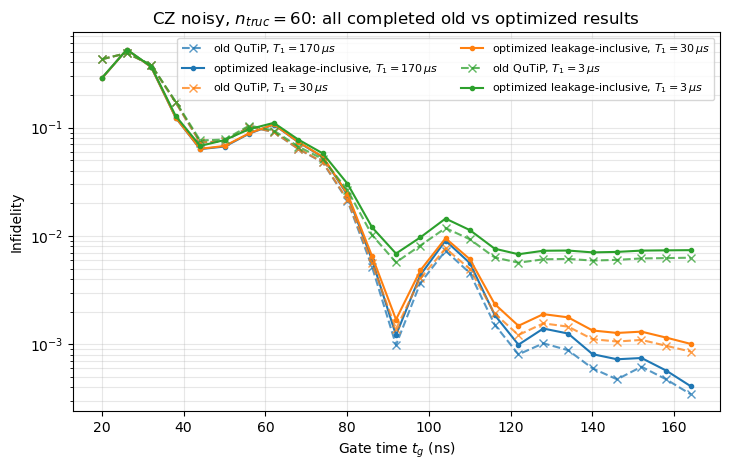

In [14]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for color, t1 in zip(["C0", "C1", "C2"], [170, 30, 3]):
    count = len(cz_new[t1])
    old_values = cz_reference[cz_old_columns[t1]].to_numpy()[:count]
    ax.plot(cz_reference["tg"].to_numpy()[:count], 10**old_values,
            "x--", color=color, alpha=0.75,
            label=rf"old QuTiP, $T_1={t1}\,\mu s$")
    ax.plot(cz_params_optimized["tg"].to_numpy()[:count], 10**cz_new[t1],
            ".-", color=color,
            label=rf"optimized leakage-inclusive, $T_1={t1}\,\mu s$")
ax.set_yscale("log")
ax.set_xlabel(r"Gate time $t_g$ (ns)")
ax.set_ylabel("Infidelity")
ax.set_title(r"CZ noisy, $n_{truc}=60$: all completed old vs optimized results")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()

## QuTiP-optimized versus leakage-inclusive-optimized pulse tables

Load the three original pulse tables (optimized using the QuTiP fidelity convention) and the three new tables optimized with the leakage-inclusive convention. The plots compare ideal infidelity at each table’s own optimized gate times.

In [2]:
from pathlib import Path

# This notebook now lives in the repository root, but retain a fallback so the
# cells also work if Jupyter was started from a subdirectory.
repo = Path.cwd()
if not (repo / "figure" / "data").exists():
    candidates = [p for p in [repo, *repo.parents] if (p / "figure" / "data").exists()]
    if not candidates:
        raise FileNotFoundError("Could not locate figure/data")
    repo = candidates[0]

data_dir = repo / "figure" / "data"

comparison_tables = {
    "phi": {
        "qutip": pd.read_csv(data_dir / "data_xgate_phi_mstep_1e3_npz.txt"),
        "leakage": pd.read_csv(data_dir / "data_xgate_phi_fidelity_leakage.txt"),
        "qutip_log_column": "f_charge_160_npz",
        "leakage_log_column": "f_leakage_160",
        "title": r"X gate, $n_\phi$ ($n_{truc}=160$)",
    },
    "theta": {
        "qutip": pd.read_csv(data_dir / "data_xgate_theta_mstep_3e4_npz.txt"),
        "leakage": pd.read_csv(data_dir / "data_xgate_theta_fidelity_leakage.txt"),
        "qutip_log_column": "f_157_charge",
        "leakage_log_column": "f_leakage_157",
        "title": r"X gate, $n_\theta$ ($n_{truc}=157$)",
    },
    "cz": {
        "qutip": pd.read_csv(data_dir / "data_cz_fidelity_npz_select.txt"),
        "leakage": pd.read_csv(data_dir / "data_cz_fidelity_leakage.txt"),
        "qutip_log_column": "f_charge_60",
        "leakage_log_column": "f_leakage_60",
        "title": r"CZ ($n_{truc}=60$)",
    },
}

for gate, tables in comparison_tables.items():
    print(gate, {name: len(tables[name]) for name in ("qutip", "leakage")})


phi {'qutip': 19, 'leakage': 19}
theta {'qutip': 18, 'leakage': 18}
cz {'qutip': 30, 'leakage': 30}


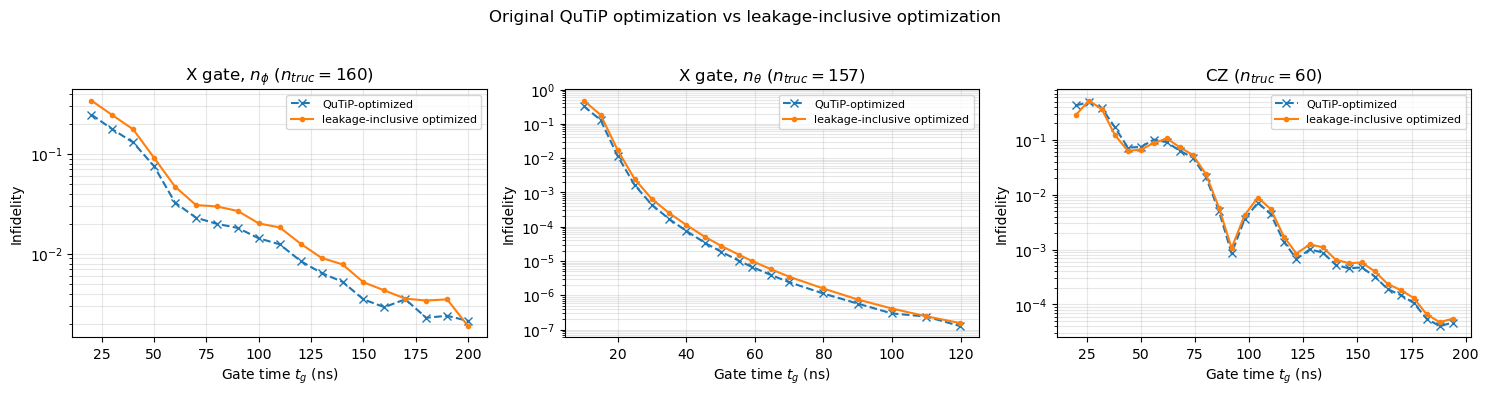

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

for ax, (gate, tables) in zip(axes, comparison_tables.items()):
    qutip = tables["qutip"]
    leakage = tables["leakage"]

    ax.plot(
        qutip["tg"],
        10.0 ** qutip[tables["qutip_log_column"]],
        "x--",
        label="QuTiP-optimized",
    )
    ax.plot(
        leakage["tg"],
        10.0 ** leakage[tables["leakage_log_column"]],
        ".-",
        label="leakage-inclusive optimized",
    )
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Infidelity")
    ax.set_title(tables["title"])
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Original QuTiP optimization vs leakage-inclusive optimization", y=1.03)
fig.tight_layout()


# Final optimized noisy fidelity — all gate times

Complete leakage-inclusive noisy results for all optimized Phi (19), corrected Theta (18), and CZ (30) pulse points. Each subplot contains T1=Tphi = 170, 30, and 3 μs.

In [3]:
# Load the final exported tables, which now include ideal and all noisy columns.
from pathlib import Path
repo = Path.cwd()
if not (repo / "figure").exists():
    repo = repo.parent

phi_leakage_data = pd.read_csv(repo / "figure/data/data_xgate_phi_fidelity_leakage.txt")
theta_leakage_data = pd.read_csv(repo / "figure/data/data_xgate_theta_fidelity_leakage.txt")
cz_leakage_data = pd.read_csv(repo / "figure/data/data_cz_fidelity_leakage.txt")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
plot_specs = [
    (axes[0], phi_leakage_data, "160", r"X gate, $n_\phi$, $n_{truc}=160$"),
    (axes[1], theta_leakage_data, "157", r"X gate, $n_\theta$, $n_{truc}=157$"),
    (axes[2], cz_leakage_data, "60", r"CZ, $n_{truc}=60$"),
]

for ax, table, ntruc, title in plot_specs:
    for color, t1 in zip(["C0", "C1", "C2"], [170, 30, 3]):
        log10_infidelity = table[f"f_leakage_{ntruc}_{t1}us"].to_numpy()
        ax.plot(table["tg"], 10**log10_infidelity, ".-", color=color,
                label=rf"$T_1=T_\phi={t1}\,\mu s$")
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Leakage-inclusive infidelity")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()

NameError: name 'pd' is not defined

## Leakage-inclusive optimized pulses: small truncation versus n=1000

All curves use the leakage-inclusive fidelity and the same leakage-inclusive optimized pulse tables. For the X-gate calculations, `n_full=1000` with charge selection retained 521 Phi states and 507 Theta states; CZ used `n_truc=1000`.

In [ ]:
# Load the augmented leakage-inclusive optimized tables.
leakage_n1000_tables = {
    "phi": pd.read_csv(repo / "figure/data/data_xgate_phi_fidelity_leakage.txt"),
    "theta": pd.read_csv(repo / "figure/data/data_xgate_theta_fidelity_leakage.txt"),
    "cz": pd.read_csv(repo / "figure/data/data_cz_fidelity_leakage.txt"),
}

small_columns = {"phi": "f_leakage_160", "theta": "f_leakage_157", "cz": "f_leakage_60"}
titles = {
    "phi": r"X gate, $n_\phi$",
    "theta": r"X gate, $n_\theta$",
    "cz": "CZ",
}


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, gate in zip(axes, ["phi", "theta", "cz"]):
    table = leakage_n1000_tables[gate]
    small_column = small_columns[gate]
    small_n = small_column.rsplit("_", 1)[-1]
    ax.plot(table["tg"], 10.0 ** table[small_column], ".-", label=rf"small $n={small_n}$")
    ax.plot(table["tg"], 10.0 ** table["f_leakage_1000"], "x--", label=r"$n=1000$")
    ax.set_yscale("log")
    ax.set_xlabel(r"Gate time $t_g$ (ns)")
    ax.set_ylabel("Infidelity")
    ax.set_title(titles[gate])
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Leakage-inclusive optimized pulses: truncation comparison", y=1.03)
fig.tight_layout()
